In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from kaggle.api.kaggle_api_extended import KaggleApi
import os
import torch 
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from pathlib import Path
import cv2
import numpy as np
import json
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from tqdm import tqdm
import random
import shutil
import yaml
from ultralytics import YOLO
import torch 
import shutil

from yaml_Creator import *
from help_fun import *

%matplotlib inline

### Download data



In [42]:
download_dir = '/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k'

if not os.path.exists(download_dir):
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files('solesensei/solesensei_bdd100k', path=download_dir, unzip=True)
    print("dowloand and unzip")
else:
    print("Data is avilable")

Data is avilable


In [43]:
df = pd.read_json('/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train.json')

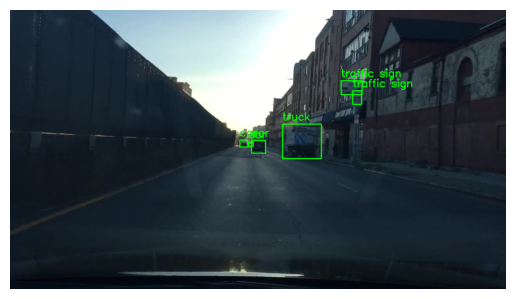

In [ ]:
img_name = '0a0c3694-9572f64f.jpg'
path = os.path.join('/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k/bdd100k/images/100k/train', img_name)
img = imread_rgb(path)

sample = df[df['name'] == img_name]


for s in sample['labels'].to_list()[0]:
    if 'box2d' in s:
        box = s['box2d']
        
        x1, y1 = int(box['x1']), int(box['y1'])
        x2, y2 = int(box['x2']), int(box['y2'])

        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0),2)
        category = s['category']
        cv2.putText(img, category, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

plot(img)

In [6]:
df.head(1)

,name,attributes,timestamp,labels
0,0000f77c-6257be58.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'traffic light', 'attributes': {..."


### Create .yaml file

In [ ]:
from yaml_Creator import json2yaml
from pathlib import Path

train_img_path = Path('/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k/bdd100k/images/100k/train')
train_label_path = Path('/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train.json')

j2y = json2yaml(train_img_path, train_label_path)

output_txt_dir = '/home/plorenc/Desktop/ADAS_for_poor/100_data'
j2y.create_txt_cord(output_txt_dir)

output_yaml_path = '/home/plorenc/Desktop/ADAS_for_poor/yolov5_config.yaml'
j2y.create_yaml(output_yaml_path)

# Train yolo v8 nano

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = YOLO("yolov8n.pt").to(device)

100%|██████████| 6.25M/6.25M [00:00<00:00, 27.7MB/s]


In [ ]:
model.train(
    data='/home/plorenc/Desktop/ADAS_for_poor/yolov5_config.yaml',
    epochs=100,
    imgsz=640,
    device=device
)

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/100      2.25G      1.176     0.6586      0.925         68        640: 100%|██████████| 148/148 [00:25<00:00,  5.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 20/20 [00:03<00:00,  5.14it/s]
                   all        617      11836      0.466      0.338      0.348      0.187

In [ ]:
model.save('yolo8n_100.pt')

### Load model (yolov8n)

In [13]:
model = YOLO('/home/plorenc/Desktop/ADAS_for_poor/yolo8n_100.pt')


0: 384x640 1 bus, 6 cars, 1 traffic light, 14.9ms
Speed: 16.1ms preprocess, 14.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


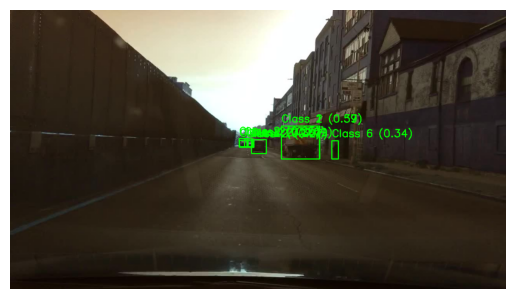

In [18]:
img = imread_rgb(path)

results = model(img)[0]


boxes = results.boxes.xyxy  
confidences = results.boxes.conf 
classes = results.boxes.cls 

img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box.tolist())  
    class_id = int(classes[i].item()) 
    confidence = confidences[i].item()  
    
    cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)  

    label = f"Class {class_id} ({confidence:.2f})"
    cv2.putText(img_cv, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

plot(img_cv)

# Train yolo v11 nano

In [45]:
from ultralytics import YOLO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = YOLO("yolo12n.pt").to(device)

100%|██████████| 5.34M/5.34M [00:00<00:00, 29.8MB/s]


In [ ]:
chkepoint_path = Path("/home/plorenc/Desktop/ADAS_for_poor/chekpoints")
chkepoint_path.mkdir(exist_ok=True)

model_path = "yolov11n_100.pt"

for i in (range(10)):
    model = YOLO(model_path).to(device)

    model.train(
        data='/home/plorenc/Desktop/ADAS_for_poor/yolo_config_100.yaml',
        epochs=5,
        imgsz=640,
        batch=16,
        device=device,
        save_period=1,
        save_dir=str(chkepoint_path)
    )

    model_path = os.path.join(chkepoint_path, f"model_{i}.pt")
    model.save(model_path)
    print(f'{i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i, i}')


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        5/5      4.89G      1.317     0.8005     0.9848        247        640: 100%|██████████| 3494/3494 [16:28<00:00,  3.53it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 437/437 [01:39<00:00,  4.39it/s]
                   all      13967     258389      0.631      0.381      0.407      0.222

5 epochs completed in 1.515 hours.
Optimizer stripped from /home/plorenc/Desktop/AiR_ISS/runs/detect/train19/weights/last.pt, 5.5MB
Optimizer stripped from /home/plorenc/Desktop/AiR_ISS/runs/detect/train19/weights/best.pt, 5.5MB

Validating /home/plorenc/Desktop/AiR_ISS/runs/detect/train19/weights/best.pt...
Ultralytics 8.3.161 🚀 Python-3.12.3 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2060, 5918MiB)
YOLOv12n summary (fused): 159 layers, 2,558,678 parameters, 0 gradients, 6.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 437/437 [01:44<00:00,  4.19it/s]
                   all      13967     258389      0.629      0.381      0.407      0.222
                  bike        896       1487      0.573      0.274      0.318       0.14
                   bus       1864       2445      0.591      0.477      0.509       0.39
                   car      13796     142685      0.685      0.674      0.712      0.436
                 motor        470        611      0.596      0.241      0.274      0.125
                person       4477      18358      0.559      0.467      0.488      0.226
                 rider        739        929      0.528      0.286      0.311      0.135
         traffic light       7932      37280      0.563      0.432      0.435      0.151
          traffic sign      11484      48450       0.64      0.458      0.499      0.246
                 train         15         20          1          0    0.00947    0.00379
                 truck       3795       6124      0.557      0.505      0.517      0.366
Speed: 0.1ms preprocess, 1.9ms inference, 0.0ms loss, 1.3ms postprocess per imag

In [ ]:
model = YOLO('/home/plorenc/Desktop/ADAS_for_poor/chekpoints/model_2.pt').to(device)

model.train(
    data='/home/plorenc/Desktop/ADAS_for_poor/yolo_config_100.yaml',
    epochs=15,
    imgsz=640,
    batch=16,
    device=device,
    save_period=1,
    save_dir=str(chkepoint_path)
)

model.save(r'/home/plorenc/Desktop/ADAS_for_poor/chekpoints/best.pt')

engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/plorenc/Desktop/ADAS_for_poor/yolo_config_100.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/plorenc/Desktop/ADAS_for_poor/chekpoints/model_2.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train21, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True,

train: Scanning /home/plorenc/Desktop/ADAS_for_poor/100_data/train/labels.cache... 55896 images, 0 backgrounds, 0 corrupt: 100%|██████████| 55896/55896 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 391.5±105.5 MB/s, size: 39.3 KB)


val: Scanning /home/plorenc/Desktop/ADAS_for_poor/100_data/val/labels.cache... 13967 images, 0 backgrounds, 0 corrupt: 100%|██████████| 13967/13967 [00:00<?, ?it/s]

val: /home/plorenc/Desktop/ADAS_for_poor/100_data/val/images/75055858-7d04a650.jpg: 1 duplicate labels removed
val: /home/plorenc/Desktop/ADAS_for_poor/100_data/val/images/8b94691f-0b47c5c3.jpg: 1 duplicate labels removed


...

                   all      13967     258389      0.646      0.383      0.418       0.23

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      15/15      3.48G      1.329     0.7704     0.9776         99        640: 100%|██████████| 3494/3494 [15:10<00:00,  3.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 437/437 [01:36<00:00,  4.52it/s]


                   all      13967     258389      0.651      0.383      0.419      0.231

15 epochs completed in 4.380 hours.
Optimizer stripped from /home/plorenc/Desktop/AiR_ISS/runs/detect/train21/weights/last.pt, 5.5MB
Optimizer stripped from /home/plorenc/Desktop/AiR_ISS/runs/detect/train21/weights/best.pt, 5.5MB

Validating /home/plorenc/Desktop/AiR_ISS/runs/detect/train21/weights/best.pt...
Ultralytics 8.3.161 🚀 Python-3.12.3 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2060, 5918MiB)
YOLOv12n summary (fused): 159 layers, 2,558,678 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 437/437 [01:37<00:00,  4.46it/s]


                   all      13967     258389      0.652      0.383      0.419      0.231
                  bike        896       1487      0.587      0.277      0.327      0.146
                   bus       1864       2445      0.626      0.468      0.524        0.4
                   car      13796     142685      0.701       0.68       0.72      0.442
                 motor        470        611      0.599      0.244      0.296      0.141
                person       4477      18358      0.603      0.451      0.491      0.231
                 rider        739        929      0.547      0.291      0.321       0.15
         traffic light       7932      37280      0.599      0.448      0.459      0.162
          traffic sign      11484      48450       0.66      0.463      0.513      0.257
                 train         15         20          1          0    0.00201   0.000403
                 truck       3795       6124      0.602      0.504      0.538      0.384
Speed: 0.1ms preproce

In [4]:
model.save('yolov11n_100.pt')

In [47]:
model = YOLO("yolo12n.pt").to(device)
model = model.load('/home/plorenc/Desktop/ADAS_for_poor/chekpoints/best.pt')

Transferred 640/699 items from pretrained weights



0: 384x640 1 person, 10.8ms
Speed: 15.8ms preprocess, 10.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


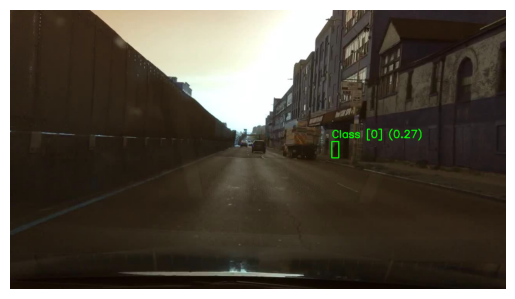

In [52]:
img = imread_rgb(path)

results = model(img)[0]

boxes = results.boxes.xyxy  
confidences = results.boxes.conf 
classes = results.boxes.cls 

img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box.tolist())  
    class_id = int(classes[i].item()) 
    confidence = confidences[i].item()  
    
    cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)  

    label = f"Class {[class_id]} ({confidence:.2f})"
    cv2.putText(img_cv, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

plot(img_cv)

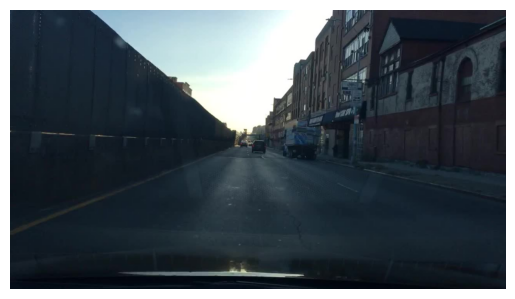

In [49]:
plot(img)

# Kitty finetune


In [ ]:
import kagglehub

path = kagglehub.dataset_download("klemenko/kitti-dataset")
print("Path to dataset files:", path)

100%|██████████| 22.5G/22.5G [10:36<00:00, 37.9MB/s]  

Extracting files...


Path to dataset files: /home/plorenc/.cache/kagglehub/datasets/klemenko/kitti-dataset/versions/1


In [2]:
folder_labels = Path('/home/plorenc/Desktop/ADAS_for_poor/kitty_dataset/data_object_label_2/training/label_2')
folder_images = Path('/home/plorenc/Desktop/ADAS_for_poor/kitty_dataset/data_object_image_2/training/image_2')

t2y = txt2yaml(folder_images=folder_images,
               folder_labels=folder_labels)

t2y.create_txt('/home/plorenc/Desktop/ADAS_for_poor/kitty_for_yolo')

### Cast label kitty to yolo

In [44]:
import os
from typing import Iterator

kitty_to_yolo = {
    'Car': ['car', 2],
    'Van': ['car', 2],
    'Truck': ['truck', 9],
    'Pedestrian': ['person', 4],
    'Person_sitting': ['person', 4],
    'Cyclist': ['rider', 5],
    'Tram': ['train', 8],
    'Misc': None,
    'DontCare': None
}


def gen_abs_path(path: str) -> Iterator[str]:
    for f in os.listdir(path):
        yield os.path.join(path, f)


train_path = "/home/plorenc/Desktop/ADAS_for_poor/kitty_for_yolo/kitty/train/labels"
test_path = "/home/plorenc/Desktop/ADAS_for_poor/kitty_for_yolo/kitty/test/labels"

for f in gen_abs_path(path):
    with open(f, 'r') as file:
        lines = file.read().splitlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if not parts:
            continue
        class_name = parts[0]
        yolo_class = kitty_to_yolo.get(class_name)
        if yolo_class is None:
            continue 
        parts[0] = str(yolo_class[1]) 
        new_lines.append(' '.join(parts))

    with open(f, 'w') as file:
        file.write('\n'.join(new_lines))


for f in gen_abs_path(test_path):
    with open(f, 'r') as file:
        lines = file.read().splitlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if not parts:
            continue
        class_name = parts[0]
        yolo_class = kitty_to_yolo.get(class_name)
        if yolo_class is None:
            continue 
        parts[0] = str(yolo_class[1]) 
        new_lines.append(' '.join(parts))

    with open(f, 'w') as file:
        file.write('\n'.join(new_lines))

In [5]:
model = YOLO('/home/plorenc/Desktop/ADAS_for_poor/chekpoints/best.pt').to(device)

model.train(
    data='/home/plorenc/Desktop/ADAS_for_poor/yolo_config_100.yaml',
    epochs=15,
    imgsz=640,
    batch=16,
    device=device,
    save_period=1,
)

model.save(r'/home/plorenc/Desktop/ADAS_for_poor/chekpoints/best_kitty.pt')

New https://pypi.org/project/ultralytics/8.3.162 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/plorenc/Desktop/ADAS_for_poor/yolo_config_100.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/plorenc/Desktop/ADAS_for_poor/chekpoints/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train24, nbs=64, nms=False, opset=None, optimize=False, optimi

train: Scanning /home/plorenc/Desktop/ADAS_for_poor/100_data/train/labels.cache... 55896 images, 0 backgrounds, 0 corrupt: 100%|██████████| 55896/55896 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1112.9±282.6 MB/s, size: 39.3 KB)


val: Scanning /home/plorenc/Desktop/ADAS_for_poor/100_data/val/labels.cache... 13967 images, 0 backgrounds, 0 corrupt: 100%|██████████| 13967/13967 [00:00<?, ?it/s]

val: /home/plorenc/Desktop/ADAS_for_poor/100_data/val/images/75055858-7d04a650.jpg: 1 duplicate labels removed
val: /home/plorenc/Desktop/ADAS_for_poor/100_data/val/images/8b94691f-0b47c5c3.jpg: 1 duplicate labels removed


...

                   all      13967     258389      0.653      0.393      0.426      0.235

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      15/15      3.46G      1.319     0.7578      0.975         99        640: 100%|██████████| 3494/3494 [14:50<00:00,  3.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 437/437 [01:22<00:00,  5.29it/s]


                   all      13967     258389      0.659      0.389      0.427      0.236

15 epochs completed in 4.170 hours.
Optimizer stripped from /home/plorenc/Desktop/AiR_ISS/runs/detect/train24/weights/last.pt, 5.5MB
Optimizer stripped from /home/plorenc/Desktop/AiR_ISS/runs/detect/train24/weights/best.pt, 5.5MB

Validating /home/plorenc/Desktop/AiR_ISS/runs/detect/train24/weights/best.pt...
Ultralytics 8.3.161 🚀 Python-3.12.3 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2060, 5918MiB)
YOLOv12n summary (fused): 159 layers, 2,558,678 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 437/437 [01:21<00:00,  5.34it/s]


                   all      13967     258389      0.659      0.389      0.427      0.236
                  bike        896       1487      0.563      0.304      0.335      0.149
                   bus       1864       2445      0.643      0.466      0.533      0.406
                   car      13796     142685      0.716      0.679      0.724      0.445
                 motor        470        611      0.601      0.265      0.309      0.148
                person       4477      18358       0.62      0.448      0.498      0.235
                 rider        739        929      0.552        0.3      0.328      0.156
         traffic light       7932      37280       0.61      0.452      0.467      0.166
          traffic sign      11484      48450      0.671      0.471      0.525      0.263
                 train         15         20          1          0    0.00269   0.000539
                 truck       3795       6124      0.611      0.508      0.547      0.391
Speed: 0.1ms preproce